---
title: "Histograms and Bias/Variance Analysis"
---

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Histograms

To define the problem, we suppose that we have data $D = \left\{X_{j}\right\}_{j=1}^{N_{D}}$ where are i.i.d. and $X_{j}\sim p(x)$, where $p(x)$ is some unknown distribution.  A _histogram_, say $\hat{p}_{H}(x)$ is a model/estimator of $p(x)$.  

To construct it, if we know $x\in [a,b]$, we divide $[a,b]$ into $K$ bins of width $\delta x  = (b-a)/K$ so that 

$$
[a,b]=\cup_{l=1}^{K}[a_{l},b_{l}), ~ a_{1}=a, ~ b_{K} = b, ~b_{l}=a_{l+1}, ~ b_{l}-a_{l} = \delta x
$$ 

Define an _indicator_ function for a set $A$ as $I_{A}(x)$ so that 

$$
I_{A}(x) = \left\{
\begin{array}{rl}
1 & x \in A \\ 
0 & x \notin A
\end{array}
\right.
$$

Then $\hat{p}_{H}(x)$ is defined to be

$$
\hat{p}_{H}(x) = \frac{1}{\delta x} \sum_{l=1}^{K} \hat{p}_{l} I_{[a_{l},b_{l})}(x), ~ \hat{p}_{l} = \frac{N_{l}}{N_{D}}
$$

where $N_{l}$ is the number of data points in the $l^{th}$-bin, i.e.

$$
N_{l} = \sum_{j=1}^{N_{D}}I_{[a_{l},b_{l})}(X_{j}),
$$

so that $\sum_{l=1}^{K}N_{l} = N_{D}$.

### Cross Validation to Select $K$

So as we see, chaning bin number radically changes the appearance of your histogram and thus your estimate of the underlyin probability distribution generating your data.  How then do we make principled choices around $K$?  One way to do this, is to start from the estimation error:

\begin{align*}
\mathcal{E} = & \int_{a}^{b}\left(\hat{p}_{H}(x) - p(x) \right)^{2}dx \\ 
= & \int_{a}^{b}\left(\hat{p}_{H}(x)\right)^{2}dx - 2\int_{a}^{b} \hat{p}_{H}(x)p(x)dx + \int_{a}^{b}p^{2}(x)dx.
\end{align*}

The last term provides a constant offset that we ignore.  Now, to provide a meaningful comparison, we introduce the cross-validated *risk* function $\mathcal{J}$ where 

\begin{align*}
\mathcal{J} = & \int_{a}^{b}\left(\hat{p}_{H}(x)\right)^{2}dx - 2\int_{a}^{b}\hat{p}_{H}(x)p(x)dx\\
= & \int_{a}^{b}\left(\hat{p}_{H}(x)\right)^{2}dx - 2\mathbb{E}\left[\hat{p}_{H}(\cdot)\right]\\
\approx & \int_{a}^{b}\left(\hat{p}_{H}(x)\right)^{2}dx - \frac{2}{N_{D}}\sum_{j=1}^{N_{D}}\hat{p}_{H}(X_{j})\\
 \approx & \int_{a}^{b}\left(\hat{p}_{H}(x)\right)^{2}dx - \frac{2}{N_{D}}\sum_{j=1}^{N_{D}}\hat{p}_{H,-j}(X_{j})
\end{align*}

where $\hat{p}_{H,-j}(x)$ is the histogram generated by dropping $X_{j}$ from the data set.  We introduce this approximation so that we can cross-validate using $\hat{p}_{H}(x)$ in a way that is non-circular but also respects the fact that the given data set is our only source of information.  

*Problem*: Show that 

\begin{align*}
\int_{a}^{b}\left(\hat{p}_{H}(x)\right)^{2}dx = & \frac{1}{(\delta x)^{2}}\sum_{l,k}\hat{p}_{l}\hat{p}_{k}\int_{a}^{b}I_{[a_l,b_l)}(x)I_{[a_k,b_k)}(x)dx\\
= & \frac{1}{\delta x}\sum_{l}\hat{p}_{l}^{2}
\end{align*}

*Problem*: Show that 

\begin{align*}
\frac{1}{N_{D}}\sum_{j=1}^{N_{D}}\hat{p}_{H,-j}(X_{j}) = & \frac{1}{N_{D}\delta x}\sum_{l=1}^{K}\sum_{j=1}^{N_{D}}\hat{p}_{H,-j}I_{[a_{l},b_{l})}(X_{j})\\
= & \frac{1}{\delta x}\sum_{l=1}^{K}\frac{N_{l}(N_{l}-1)}{N_{D}(N_{D}-1)}\\
= & -\frac{1}{(N_{D}-1)\delta x} + \frac{N_{D}}{\delta x(N_{D}-1)}\sum_{l=1}^{K}\hat{p}_{l}^{2}.
\end{align*}

*Problem*: Now show that 

$$
\mathcal{J}(K) = \frac{2}{(N_{D}-1)\delta x} - \frac{(N_{D}+1)}{\delta x (N_{D}-1)}\sum_{l=1}^{K}\hat{p}_{l}^{2}.
$$

## Bias/Variance Analysis in Statistical Modeling

The abstract data analysis problem is for data say $\left\{(x_{j},y_{j})\right\}_{j=1}{N_{B}}$ where 

$$
y_{j} = f(x_{j}) + \epsilon_{j}, ~ \epsilon_{k} \sim \mathbb{P}
$$

where $f(\cdot)$ is thought of as the true relationship between domain and range but which is otherwise un-observable because of noise $\epsilon_{j}$.  Thus we have to introduce some model $f_{M}$ and approximate $y_{j} \approx f_{M}(x_{j})$.  To assess the quality of our model, we look at the mean-squared error (MSE) given by

$$
\text{MSE} = \mathbb{E}\left[\int\left(f(x) - f_{M}(x) \right)^{2} dx\right].
$$

Through a bit of wrangling, we can rewrite this as 

$$
\text{MSE} = \int\left(f(x) - \mathbb{E}\left[f_{M}(x)\right] \right)^{2} dx + \mathbb{E}\left[\int\left(f_{M}(x) - \mathbb{E}\left[f_{M}(x)\right] \right)^{2} dx\right].
$$

This then gives us $\text{MSE} = \text{Bias}^2 + \text{Variance}$ where

$$
\text{Bias}^{2} = \int\left(f(x) - \mathbb{E}\left[f_{M}(x)\right] \right)^{2} dx, ~ \text{Variance} = \mathbb{E}\left[\int\left(f_{M}(x) - \mathbb{E}\left[f_{M}(x)\right] \right)^{2} dx\right].
$$

### Bias/Variance Analysis for the Histogram

So, as we've discussed in class (and as is further explored in the homework), if we are attempting to approximate some unknown probability density $p(x)$ via a histogram $p_H(x)$, then on interval $[a,b]$, if we divide into $K$ equispaced bins so that $\delta x = (b-a)/K$, we have on each subinterval $[a_{l},b_{l}]$ that 

$$
\mathbb{E}[p_{H}(x)] = \frac{p_{l}}{\delta x}, ~ p_{l} = \int_{a_{l}}^{b_{l}}p(x) dx, ~ x\in[a_{l},b_{l}].  
$$

Following the formulas above, we can then show 

$$
\text{Bias}^{2} = \int_{a_{l}}^{b_{l}}p^{2}(x) dx - \frac{p^{2}_{l}}{\delta x}.  
$$

Likewise, as you show in the homework, we get 

$$
\text{Variance} = \frac{1}{(\delta x)^{2}N_{D}}p_{l}(1-p_{l})
$$

To study this in even more quantitative terms, lets pick $p(x)$ to be the beta-distribution so that 

$$
p(x) = \frac{\Gamma(\alpha + \beta)}{\Gamma(\alpha)\Gamma(\beta)}x^{\alpha-1}(1-x)^{\beta-1}, ~ 0\leq x \leq 1, ~ \alpha,\beta > 0.
$$

Here $\Gamma(x)$ is given by 
$$
\Gamma(x) = \int_{0}^{\infty} t^{x-1}e^{-t}dt, ~ x > 0.  
$$

*Problem*: Show $\Gamma(1) = 1$.  

*Problem*: For $x>1/2$ show that $\Gamma(x+1)=x\Gamma(x)$.  

*Problem*: For $n\in \mathbb{N}$, show that $\Gamma(n)=n!$.  

Keep in mind, we also have our cross-fold histogram estimator to determine the optimal number of bins $K$.  The formula for that is

$$
J(K) = \frac{2}{\delta x (N_{D}-1)} - \delta x\frac{N_{D}+1}{N_{D}-1}\sum_{l=1}^{K}\left(\frac{\hat{p}_{l}}{\delta x}\right)^{2}
$$

In [3]:
# cross-validator

def cross_val(bincnt, samples):
    nd = samples.size
    dx = 1./bincnt

    hist, bins = np.histogram(samples, bins=bincnt, density=True)
    error = 2./(dx * (nd-1)) - dx * (nd+1)/(nd-1) * np.sum( hist**2. )
    return bins, hist, error

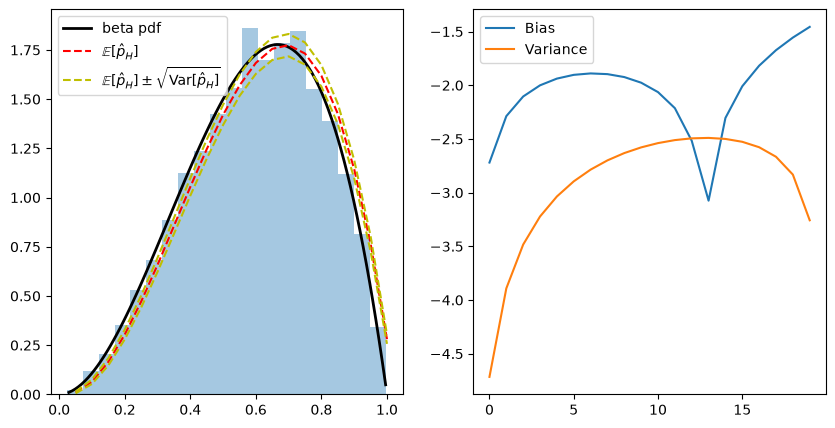

In [16]:
from scipy.stats import beta
from scipy.integrate import quad

a, b = 3., 2.
K = 20
Nd = 10000

data = beta.rvs(a, b, size=Nd) 
beta_fun = lambda x: beta.pdf(x, a, b)
beta_fun_sq = lambda x: beta.pdf(x, a, b)**2.
bins = np.linspace(0, 1., K+1)
dx = bins[1] - bins[0]

mean_ph = np.zeros(K, dtype=np.float64)
bias = np.zeros(K, dtype=np.float64)
var = np.zeros(K, dtype=np.float64)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax.ravel()

for ll in range(K):
    pll = quad(beta_fun, bins[ll], bins[ll+1])[0]
    psqll = quad(beta_fun_sq, bins[ll], bins[ll+1])[0]
    
    mean_ph[ll] = pll/dx
    bias[ll] = np.sqrt(psqll - pll**2./dx)
    var[ll] = pll*(1.-pll)/(Nd * dx**2.)

ax[0].hist(data, density=True, bins=K, alpha=0.4)
x = np.linspace(beta.ppf(0.0001, a, b), beta.ppf(0.9999, a, b), 100)
ax[0].plot(x, beta.pdf(x, a, b), 'k-', lw=2, alpha=1, label='beta pdf')
ax[0].plot(bins[1:], mean_ph, 'r--',label=r'$\mathbb{E}[\hat{p}_{H}]$')
ax[0].plot(bins[1:], mean_ph+np.sqrt(var), 'y--', label=r'$\mathbb{E}[\hat{p}_{H}] \pm \sqrt{\text{Var}[\hat{p}_{H}]}$')
ax[0].plot(bins[1:], mean_ph-np.sqrt(var), 'y--')
ax[0].legend()

ax[1].plot(np.log10(bias), label='Bias')
ax[1].plot(np.log10(var), label='Variance')
ax[1].legend()




Let's also look at how $J(K)$ changes for different $K$.  

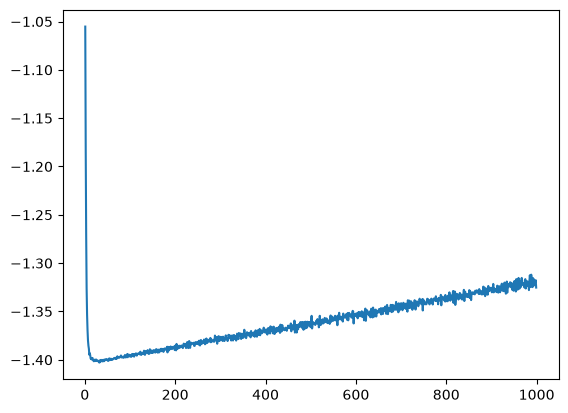

In [15]:
bincnts = np.arange(1,1000) # Explore bin counts 
errors = np.zeros(len(bincnts))
for jj, bincnt in enumerate(bincnts):
    bins, hist, error = cross_val(bincnt, data)
    errors[jj] = error

plt.plot(bincnts, errors)